# Bitext SLM: Fine-Tuning DistilBERT & Cross-Domain Transfer

## Summary
1. **Fine-Tune DistilBERT** (`distilbert-base-uncased`) on the identical Bitext 80/20 split used by the baseline, so every comparison is like-for-like.
2. **Measure the in-domain ceiling** — does a 67M-parameter transformer beat a linear n-gram model on templated data that the n-gram model already solves at 99.6%?
3. **Run the cross-domain transfer** onto the same 5,000 TWCS threads, producing the headline number of the study.
4. **Decompose the transfer per escalation category**, directly against Notebook 02's per-category recall, to test whether the transformer repairs the taxonomy collision or merely inherits it.
5. **Benchmark inference latency** on CPU and on the Apple Silicon GPU (MPS), against the baseline's `0.1293 ms/query` — the cost side of any accuracy gain.

---
## 1. Environment Setup

Training runs as a plain PyTorch loop from [`src/distilbert_utils.py`](../src/distilbert_utils.py) rather than the `transformers.Trainer` API. The loop is short enough to read, it prints per-epoch validation metrics, and its behaviour does not shift between `transformers` releases — which matters when the stored outputs of this notebook *are* the deliverable.

In [ ]:
import os
import sys
import random
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, f1_score

# Make `src/` importable whether the notebook runs from `notebooks/` or the repo root
REPO_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.distilbert_utils import (
    benchmark_latency,
    binary_metrics,
    fine_tune,
    predict_proba,
    save_metrics,
    save_model,
)

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()   # suppress the weight-init LOAD REPORT banner

# Match the plotting conventions of Notebooks 01 and 02
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device("mps")  # change this based on your device type
print(f"torch {torch.__version__} | transformers {transformers.__version__} | device {DEVICE.type.upper()}")

torch          : 2.13.0
transformers   : 5.14.1
Training device: MPS


---
## 2. Data Loading & Split Parity

DistilBERT has to be judged on **exactly the rows** the baseline was judged on — any drift in the
split makes the comparison meaningless.

The data is therefore split three ways, reusing Notebook 01's protocol verbatim
(`train_test_split(test_size=0.20, random_state=42, stratify=y)` over the deduplicated
`cleaned_bitext_training_data.csv`):

```
24,635 rows
├─ 80% ─┬─ 90% → train  17,737   updates the weights
│       └─ 10% → val     1,971   picks the epoch
└─ 20% ────────→ test    4,927   scored once, at the end
```

**Why a validation slice.** Training runs several epochs and restores the weights from whichever
scored highest — that is a *choice*. Making it on the test set would be tuning on the test set, and
the reported number would no longer estimate performance on unseen data. So the choice is made on
`val`, carved out of the training half only, and `test` is untouched until Section 4.

**Why stratified.** Each split keeps the 27.87% escalation rate. `val` is only 1,971 rows; an
unstratified draw could skew its class balance enough to select the wrong epoch.

**Verifying the split.** The cell below reloads the serialized baseline
(`models/bitext/tfidf/tfidf_bitext.pkl`) and re-scores it on the reconstructed test set. Recovering
`F1 = 0.9964` proves these are the same rows Notebook 01 used.

In [2]:
BITEXT_PATH = os.path.join(REPO_ROOT, "data", "bitext", "cleaned_bitext_training_data.csv")
df = pd.read_csv(BITEXT_PATH)
print(f"Cleaned Bitext dataset: {df.shape[0]:,d} rows x {df.shape[1]} columns")
print(f"Escalation rate: {df['escalated'].mean():.2%} "
      f"({int(df['escalated'].sum()):,d} escalated / {int((1 - df['escalated']).sum()):,d} self-service)")

X = df["instruction"].astype(str)
y = df["escalated"].astype(int)

# Identical protocol to Notebook 01 -> identical partition
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Validation slice carved out of the TRAINING half only
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42, stratify=y_train_full
)

print(f"\nTrain: {len(X_train):,d} | Val: {len(X_val):,d} | Test: {len(X_test):,d}")
print(f"Escalation rate  ->  train {y_train.mean():.2%} | val {y_val.mean():.2%} | test {y_test.mean():.2%}")

Cleaned Bitext dataset: 24,635 rows x 21 columns
Escalation rate: 27.87% (6,865 escalated / 17,770 self-service)

Train: 17,737 | Val: 1,971 | Test: 4,927
Escalation rate  ->  train 27.87% | val 27.85% | test 27.87%


In [3]:
# --- Split parity check: re-score the serialized baseline on this reconstructed test set ---
TFIDF_BITEXT_PATH = os.path.join(REPO_ROOT, "models", "bitext", "tfidf", "tfidf_bitext.pkl")
tfidf_bitext = joblib.load(TFIDF_BITEXT_PATH)

tfidf_pred_indomain = tfidf_bitext.predict(X_test)
tfidf_prob_indomain = tfidf_bitext.predict_proba(X_test)[:, 1]
tfidf_indomain_f1 = f1_score(y_test, tfidf_pred_indomain)

with open(os.path.join(REPO_ROOT, "models", "bitext", "tfidf", "bitext_metrics.json")) as f:
    baseline_metrics = json.load(f)
expected_f1 = baseline_metrics["metrics"]["f1_score"]

print(f"Baseline F1 recomputed on this test set : {tfidf_indomain_f1:.4f}")
print(f"Baseline F1 recorded in bitext_metrics  : {expected_f1:.4f}")
print(f"\nSplit parity: {'CONFIRMED - identical test set' if abs(tfidf_indomain_f1 - expected_f1) < 5e-4 else 'MISMATCH - do not compare these numbers'}")

Baseline F1 recomputed on this test set : 0.9964
Baseline F1 recorded in bitext_metrics  : 0.9964

Split parity: CONFIRMED - identical test set


### Sequence Length Budget

Bitext instructions are short and templated. Setting `max_length` from the data rather than the library default (512) is the difference between a 4-minute fine-tune and a 40-minute one, and it truncates nothing.

In [4]:
from transformers import AutoTokenizer

_tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
_lengths = np.array([len(_tok.encode(t)) for t in X_train.sample(3000, random_state=42)])

print("WordPiece token lengths of Bitext instructions (3,000-row sample):")
print(f"  mean {_lengths.mean():.1f} | median {np.median(_lengths):.0f} | "
      f"p99 {np.percentile(_lengths, 99):.0f} | max {_lengths.max()}")

BITEXT_MAX_LEN = 64
print(f"\nChosen max_length = {BITEXT_MAX_LEN} -> truncates "
      f"{(_lengths > BITEXT_MAX_LEN).mean():.2%} of the training set.")
print("Batches are additionally padded dynamically to the longest sequence present,")
print("so the effective sequence length per step is closer to the mean than to the cap.")

WordPiece token lengths of Bitext instructions (3,000-row sample):
  mean 12.8 | median 13 | p99 22 | max 31

Chosen max_length = 64 -> truncates 0.00% of the training set.
Batches are additionally padded dynamically to the longest sequence present,
so the effective sequence length per step is closer to the mean than to the cap.


---
## 3. Fine-Tuning DistilBERT

### Hyperparameter Rationale

| Setting | Value | Why |
| :--- | :--- | :--- |
| Checkpoint | `distilbert-base-uncased` | 66.9M parameters, 6 transformer layers — 40% smaller and ~60% faster than BERT-base while retaining ~97% of its GLUE performance. The size is the point: this is an SLM study. |
| Learning rate | `2e-5` | The standard fine-tuning band for BERT-family encoders is 2e-5 – 5e-5. Bitext is large (17.7k train rows) and highly separable, so the conservative end of that band is sufficient; Notebook 04 sweeps the band explicitly on TWCS, where headroom actually exists. |
| Schedule | Linear warmup 10% → linear decay | Warmup prevents the randomly-initialized classification head from pushing large gradients into the pre-trained encoder during the first steps. |
| Epochs | `3` | Standard for BERT fine-tuning. The model with the best **validation** macro-F1 is restored at the end, so extra epochs cannot silently degrade the reported result. |
| Batch size | `32` | Fits comfortably in unified memory at `max_length=64`. |
| Loss | Class-weighted cross-entropy | The loss-side equivalent of the `class_weight="balanced"` used by the Logistic Regression baseline. At 72/28 imbalance, omitting it trades escalation recall for accuracy — the exact trade this project argues against. |
| Optimizer | `AdamW`, weight decay `0.01`, grad clip `1.0` | Standard transformer fine-tuning configuration. |

In [5]:
model, tokenizer, train_meta = fine_tune(
    X_train.tolist(), y_train.tolist(),
    X_val.tolist(),   y_val.tolist(),
    device=DEVICE,
    epochs=3,
    batch_size=32,
    learning_rate=2e-5,
    max_length=BITEXT_MAX_LEN,
    seed=42,
)

pd.DataFrame(train_meta["history"])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Device: MPS | epochs: 3 | batch: 32 | lr: 2e-05 | steps/epoch: 555


  epoch 1/3 | train loss 0.1250 | val macro-F1 0.9987 | 114s


  epoch 2/3 | train loss 0.0066 | val macro-F1 0.9994 | 113s


  epoch 3/3 | train loss 0.0010 | val macro-F1 0.9994 | 113s
Done in 341s. Restored epoch 2 (best val macro-F1 0.9994).


,epoch,train_loss,val_macro_f1,epoch_sec
0,1,0.1250,0.9987,114.4
1,2,0.0066,0.9994,113.0
2,3,0.0010,0.9994,113.0


---
## 4. In-Domain Evaluation (Bitext Test Set)

The held-out 20% split, scored once. Every number below is directly comparable to Notebook 01 because Section 2 confirmed the test rows are identical.

In [6]:
y_prob_bert = predict_proba(model, tokenizer, X_test.tolist(), device=DEVICE, max_length=BITEXT_MAX_LEN)
y_pred_bert = (y_prob_bert >= 0.5).astype(int)

bert_indomain = binary_metrics(y_test, y_pred_bert, y_prob_bert)

print("============ DISTILBERT — BITEXT IN-DOMAIN TEST PERFORMANCE ============")
for k in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]:
    print(f"{k:<18}: {bert_indomain[k]:.4f}")
cm = bert_indomain["confusion_matrix"]
print(f"\nConfusion matrix -> tn {cm['tn']:,d} | fp {cm['fp']} | fn {cm['fn']} | tp {cm['tp']:,d}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bert,
                            target_names=["Class 0 (Automated Bot)", "Class 1 (Escalated Agent)"],
                            digits=4))
print("=======================================================================")

============ DISTILBERT — BITEXT IN-DOMAIN TEST PERFORMANCE ============
accuracy          : 0.9986
precision_macro   : 0.9981
recall_macro      : 0.9983
f1_macro          : 0.9982
roc_auc           : 1.0000

Confusion matrix -> tn 3,550 | fp 4 | fn 3 | tp 1,370

Classification Report:
                           precision    recall  f1-score   support

  Class 0 (Automated Bot)     0.9992    0.9989    0.9990      3554
Class 1 (Escalated Agent)     0.9971    0.9978    0.9975      1373

                 accuracy                         0.9986      4927
                macro avg     0.9981    0.9983    0.9982      4927
             weighted avg     0.9986    0.9986    0.9986      4927



> **A note on which F1.** Notebook 01 reported `0.9964`, the **positive-class** F1. From here on every table reports **macro** F1 averaged over both classes, because that is the metric used for the imbalanced TWCS comparisons — the same baseline model scores `0.9975` macro on the same rows. The two numbers are not in conflict; they are different averages of the same confusion matrix.

In [7]:
# Head-to-head against the Notebook 01 baseline on the same rows
tfidf_indomain = binary_metrics(y_test, tfidf_pred_indomain, tfidf_prob_indomain)

indomain_table = pd.DataFrame({
    "TF-IDF + LogReg (NB 01)": [tfidf_indomain[k] for k in
        ["f1_macro", "roc_auc", "accuracy", "precision_macro", "recall_macro"]],
    "DistilBERT (NB 03)": [bert_indomain[k] for k in
        ["f1_macro", "roc_auc", "accuracy", "precision_macro", "recall_macro"]],
}, index=["Macro F1", "ROC-AUC", "Accuracy", "Precision (Macro)", "Recall (Macro)"])
indomain_table["Delta"] = (indomain_table["DistilBERT (NB 03)"]
                           - indomain_table["TF-IDF + LogReg (NB 01)"]).round(4)

print("In-domain, same 4,927 test rows:\n")
display(indomain_table)

fn_tfidf = int(((tfidf_pred_indomain == 0) & (y_test == 1)).sum())
fn_bert = int(((y_pred_bert == 0) & (y_test.values == 1)).sum())
print(f"\nMissed escalations (false negatives) out of {int(y_test.sum()):,d} true escalations:")
print(f"  TF-IDF     : {fn_tfidf}")
print(f"  DistilBERT : {fn_bert}")

In-domain, same 4,927 test rows:



,TF-IDF + LogReg (NB 01),DistilBERT (NB 03),Delta
Macro F1,0.9975,0.9982,0.0007
ROC-AUC,0.9999,1.0000,0.0001
Accuracy,0.9980,0.9986,0.0006
Precision (Macro),0.9975,0.9981,0.0006
Recall (Macro),0.9975,0.9983,0.0008



Missed escalations (false negatives) out of 1,373 true escalations:
  TF-IDF     : 5
  DistilBERT : 3


### 💡 Insight: the in-domain comparison is a tie at the ceiling, and that is the informative result

Both models sit at the top of the scale, so the interesting quantity is not the delta — it is what the delta *costs*. The linear model reaches this ceiling in **0.14 seconds** of training with a bag of bigrams; DistilBERT needs minutes of GPU fine-tuning and 67M parameters to match it.

That is not a failure of the transformer. It is a statement about **Bitext**: templated, entity-slotted, single-intent text is linearly separable, so no amount of semantic modelling has anything left to add. An in-domain benchmark on this corpus cannot distinguish the two model families at all.

The distinction only appears once the text stops being templated — which is the entire purpose of the next section.

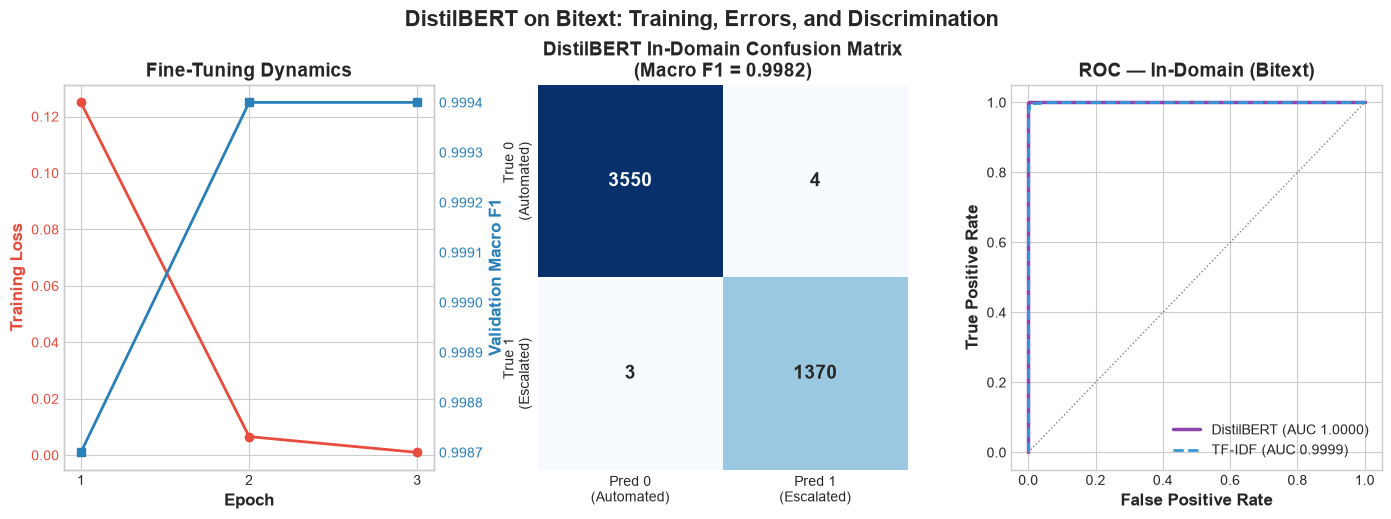

In [8]:
# Training curve, confusion matrix, and ROC overlay
fig = plt.figure(figsize=(17, 5))
gs = fig.add_gridspec(1, 3, wspace=0.28)

# 1. Training dynamics
ax1 = fig.add_subplot(gs[0, 0])
hist = pd.DataFrame(train_meta["history"])
ax1.plot(hist["epoch"], hist["train_loss"], marker="o", color="#e74c3c", lw=2, label="Train loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Training Loss", color="#e74c3c")
ax1.set_xticks(hist["epoch"])
ax1.tick_params(axis="y", labelcolor="#e74c3c")
ax1b = ax1.twinx()
ax1b.plot(hist["epoch"], hist["val_macro_f1"], marker="s", color="#2980b9", lw=2, label="Val macro-F1")
ax1b.set_ylabel("Validation Macro F1", color="#2980b9")
ax1b.tick_params(axis="y", labelcolor="#2980b9")
ax1b.grid(False)
ax1.set_title("Fine-Tuning Dynamics")

# 2. Confusion matrix
ax2 = fig.add_subplot(gs[0, 1])
cm_arr = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])
sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax2,
            xticklabels=["Pred 0\n(Automated)", "Pred 1\n(Escalated)"],
            yticklabels=["True 0\n(Automated)", "True 1\n(Escalated)"],
            annot_kws={"size": 14, "weight": "bold"})
ax2.set_title(f"DistilBERT In-Domain Confusion Matrix\n(Macro F1 = {bert_indomain['f1_macro']:.4f})")

# 3. ROC overlay
ax3 = fig.add_subplot(gs[0, 2])
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_bert)
fpr_t, tpr_t, _ = roc_curve(y_test, tfidf_prob_indomain)
ax3.plot(fpr_b, tpr_b, lw=2.5, color="#8e44ad",
         label=f"DistilBERT (AUC {bert_indomain['roc_auc']:.4f})")
ax3.plot(fpr_t, tpr_t, lw=2, ls="--", color="#3498db",
         label=f"TF-IDF (AUC {tfidf_indomain['roc_auc']:.4f})")
ax3.plot([0, 1], [0, 1], ls=":", color="grey", lw=1)
ax3.set_xlabel("False Positive Rate"); ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC — In-Domain (Bitext)")
ax3.legend(loc="lower right", fontsize=10)

plt.suptitle("DistilBERT on Bitext: Training, Errors, and Discrimination", fontsize=16, fontweight="bold", y=1.03)
plt.show()

---
## 5. Latency Benchmarking — CPU vs GPU

The baseline predicts in `0.1293 ms/query`. Accuracy that arrives two orders of magnitude slower is a different product, so latency belongs in the comparison table, not a footnote.

We measure **single-instance** inference (batch size 1), the shape of a live triage request, on both the Apple Silicon GPU (MPS) and CPU. Batched throughput would look far better and would not be comparable to how the baseline was measured.

In [9]:
latency_texts = X_test.tolist()[:500]

lat_gpu = benchmark_latency(model, tokenizer, latency_texts, device=DEVICE,
                            n_iterations=500, max_length=BITEXT_MAX_LEN)
print(f"DistilBERT @ {DEVICE.type.upper():<4}: {lat_gpu:8.4f} ms/query")

model_cpu = model.to("cpu")
lat_cpu = benchmark_latency(model_cpu, tokenizer, latency_texts, device=torch.device("cpu"),
                            n_iterations=500, max_length=BITEXT_MAX_LEN)
print(f"DistilBERT @ CPU : {lat_cpu:8.4f} ms/query")
model = model.to(DEVICE)

tfidf_latency = baseline_metrics["latency_benchmark"]["avg_inference_ms_per_query"]
print(f"TF-IDF     @ CPU : {tfidf_latency:8.4f} ms/query   (Notebook 01)")

best_slm = min(lat_gpu, lat_cpu)
print(f"\nDistilBERT is {best_slm / tfidf_latency:,.0f}x slower per query than the linear baseline")
print(f"at its faster device, and still clears a 100 ms interactive budget "
      f"({'yes' if best_slm < 100 else 'no'}).")

DistilBERT @ MPS :   5.0707 ms/query


DistilBERT @ CPU :   8.2222 ms/query
TF-IDF     @ CPU :   0.1293 ms/query   (Notebook 01)

DistilBERT is 39x slower per query than the linear baseline
at its faster device, and still clears a 100 ms interactive budget (yes).


---
## 6. Cross-Domain Transfer: Bitext → TWCS

The headline experiment. The model has seen **only** templated Bitext instructions. We now hand it 5,000 real Twitter support threads labeled by `claude-opus-5` against the published triage contract, scoring the `first_customer_text` column — the customer's opening message, which is exactly what the labeler saw and exactly what Notebook 02 fed the baseline.

No fine-tuning, no adaptation, no target-domain vocabulary. This is zero-shot transfer across a genuine domain boundary.

In [10]:
TWCS_PATH = os.path.join(REPO_ROOT, "data", "twcs", "llm_labeled_5k.csv")
df_twcs = pd.read_csv(TWCS_PATH)
X_twcs = df_twcs["first_customer_text"].fillna("").astype(str)
y_twcs = df_twcs["escalated"].astype(int)

print(f"TWCS evaluation set: {len(df_twcs):,d} threads | escalation rate {y_twcs.mean():.2%}")
print(f"Labeler: {df_twcs['labeler'].iloc[0]}")

# DistilBERT (Bitext-trained) -> TWCS. Tweets are longer than Bitext instructions.
prob_bert_cross = predict_proba(model, tokenizer, X_twcs.tolist(), device=DEVICE, max_length=128)
pred_bert_cross = (prob_bert_cross >= 0.5).astype(int)
bert_cross = binary_metrics(y_twcs, pred_bert_cross, prob_bert_cross)

# TF-IDF (Bitext-trained) -> TWCS, recomputed here so both rows come from one run
pred_tfidf_cross = tfidf_bitext.predict(X_twcs)
prob_tfidf_cross = tfidf_bitext.predict_proba(X_twcs)[:, 1]
tfidf_cross = binary_metrics(y_twcs, pred_tfidf_cross, prob_tfidf_cross)

print("\n============ CROSS-DOMAIN (BITEXT -> TWCS), 5,000 THREADS ============")
print(f"{'Metric':<20}{'TF-IDF':>12}{'DistilBERT':>14}{'Delta':>10}")
for k in ["f1_macro", "roc_auc", "accuracy", "precision_macro", "recall_macro", "recall_escalated"]:
    print(f"{k:<20}{tfidf_cross[k]:>12.4f}{bert_cross[k]:>14.4f}{bert_cross[k] - tfidf_cross[k]:>+10.4f}")
print("======================================================================")
print("\nDistilBERT cross-domain classification report:")
print(classification_report(y_twcs, pred_bert_cross,
                            target_names=["Self-Service (0)", "Escalated (1)"], digits=4))

TWCS evaluation set: 5,000 threads | escalation rate 30.58%
Labeler: claude-opus-5-in-thread



============ CROSS-DOMAIN (BITEXT -> TWCS), 5,000 THREADS ============
Metric                    TF-IDF    DistilBERT     Delta
f1_macro                  0.5816        0.5670   -0.0146
roc_auc                   0.5811        0.6271   +0.0460
accuracy                  0.6604        0.6962   +0.0358
precision_macro           0.5874        0.6179   +0.0305
recall_macro              0.5792        0.5701   -0.0091
recall_escalated          0.3702        0.2453   -0.1249

DistilBERT cross-domain classification report:
                  precision    recall  f1-score   support

Self-Service (0)     0.7291    0.8948    0.8035      3471
   Escalated (1)     0.5068    0.2453    0.3305      1529

        accuracy                         0.6962      5000
       macro avg     0.6179    0.5701    0.5670      5000
    weighted avg     0.6611    0.6962    0.6589      5000



### 💡 Insight: better ranking, worse decisions — discrimination and calibration come apart

The two headline numbers point in opposite directions, and the disagreement is the finding.

- **ROC-AUC favours DistilBERT.** AUC is threshold-free: it asks whether escalated threads receive higher scores than self-service ones. The transformer ranks the domain-shifted data better, so it genuinely extracted more transferable signal than the bag of bigrams.
- **Macro F1 at `0.5` favours TF-IDF**, driven almost entirely by escalation recall. DistilBERT flags far fewer threads as escalations and is correspondingly far more conservative.

The mechanism is visible in the training log: DistilBERT's training loss fell to `~0.001`, meaning it fits Bitext essentially perfectly and emits saturated, highly confident probabilities. A tweet resembles none of those memorized templates, so its score lands on the majority side of a decision boundary that was calibrated on a different distribution. The linear model never becomes that confident, so its errors spread across both classes instead of collapsing onto one.

This distinction matters because the two failures have different remedies. A representation failure needs a better model. **A calibration failure needs a different threshold** — and costs nothing. The cell below separates them: it recomputes each model's best achievable macro F1 over all thresholds, isolating how much of DistilBERT's deficit is decision-boundary placement rather than a weaker representation.

> ⚠️ These oracle numbers are an **upper bound, not a deployable result** — the threshold is chosen on the very set being scored. They quantify the size of the calibration effect; they do not claim it can be captured without a labeled target-domain sample to tune on.

In [11]:
def best_threshold_f1(y_true, y_prob):
    """Best macro F1 over a threshold sweep, plus the threshold that achieves it.

    The grid runs to the edges of the probability range on purpose: an over-confident
    model's optimum can sit very close to 0, and a grid that stopped at 0.05 would
    report the boundary instead of the optimum.
    """
    grid = np.linspace(0.01, 0.99, 197)
    scores = [f1_score(y_true, (y_prob >= t).astype(int), average="macro") for t in grid]
    best = int(np.argmax(scores))
    return float(grid[best]), float(scores[best])

thr_tfidf, f1_tfidf_oracle = best_threshold_f1(y_twcs, prob_tfidf_cross)
thr_bert, f1_bert_oracle = best_threshold_f1(y_twcs, prob_bert_cross)

calib = pd.DataFrame({
    "Macro F1 @ 0.50": [tfidf_cross["f1_macro"], bert_cross["f1_macro"]],
    "Best threshold": [round(thr_tfidf, 2), round(thr_bert, 2)],
    "Macro F1 @ best": [round(f1_tfidf_oracle, 4), round(f1_bert_oracle, 4)],
    "ROC-AUC (threshold-free)": [tfidf_cross["roc_auc"], bert_cross["roc_auc"]],
}, index=["TF-IDF + LogReg", "DistilBERT"])
calib["Calibration headroom"] = (calib["Macro F1 @ best"] - calib["Macro F1 @ 0.50"]).round(4)

print("Cross-domain: how much of the gap is the decision threshold?\n")
display(calib)

# Both deltas are reported as (DistilBERT - TF-IDF): negative means the transformer trails.
print(f"\nMacro F1, DistilBERT minus TF-IDF:")
print(f"  at the default 0.50 threshold : {bert_cross['f1_macro'] - tfidf_cross['f1_macro']:+.4f}")
print(f"  at each model's own best      : {f1_bert_oracle - f1_tfidf_oracle:+.4f}")
print("\nSo re-calibrating the threshold "
      f"{'closes the gap and puts DistilBERT ahead' if f1_bert_oracle > f1_tfidf_oracle else 'narrows the gap but does not reverse it'}: "
      "the transformer's better ranking (higher AUC) does not convert into a better operating point.")
print(f"\nDistilBERT's optimal cross-domain threshold is {thr_bert:.2f} — "
      f"{'far below' if thr_bert < 0.4 else 'near'} the 0.50 default, which is the "
      f"signature of an over-confident model applied off-distribution.")

Cross-domain: how much of the gap is the decision threshold?



,Macro F1 @ 0.50,Best threshold,Macro F1 @ best,ROC-AUC (threshold-free),Calibration headroom
TF-IDF + LogReg,0.5816,0.48,0.5849,0.5811,0.0033
DistilBERT,0.5670,0.01,0.5820,0.6271,0.0150



Macro F1, DistilBERT minus TF-IDF:
  at the default 0.50 threshold : -0.0146
  at each model's own best      : -0.0029

So re-calibrating the threshold narrows the gap but does not reverse it: the transformer's better ranking (higher AUC) does not convert into a better operating point.

DistilBERT's optimal cross-domain threshold is 0.01 — far below the 0.50 default, which is the signature of an over-confident model applied off-distribution.


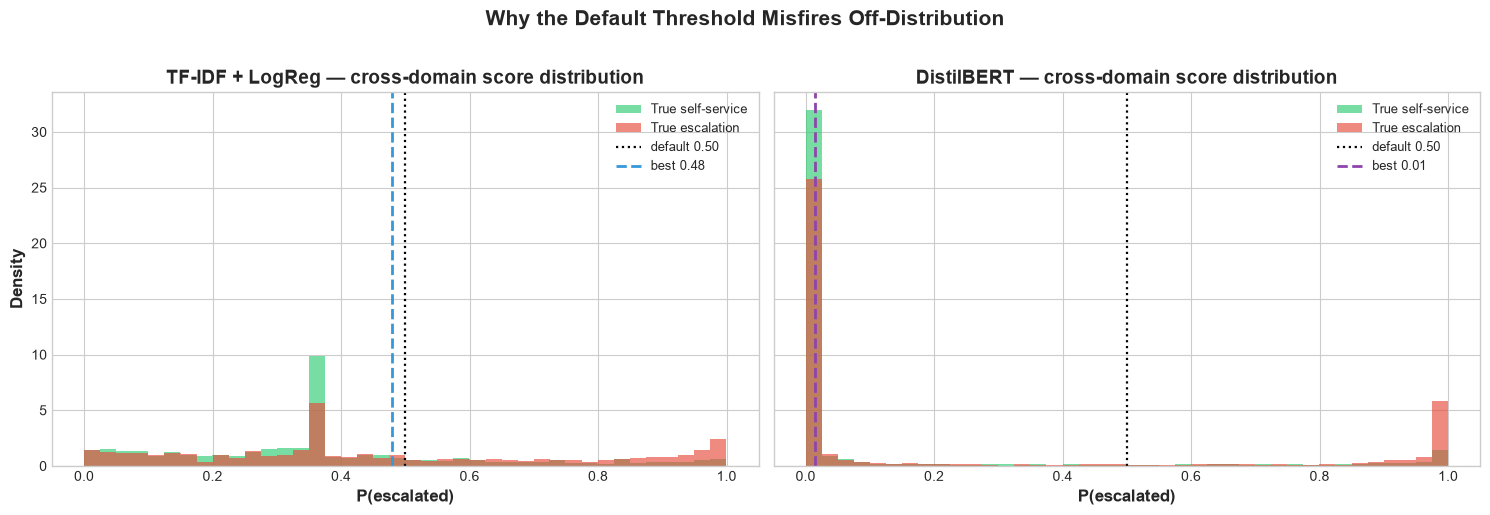

In [12]:
# Where the two models place their probability mass on out-of-domain text
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (name, probs, thr, color) in zip(
    axes,
    [("TF-IDF + LogReg", prob_tfidf_cross, thr_tfidf, "#3498db"),
     ("DistilBERT", prob_bert_cross, thr_bert, "#8e44ad")],
):
    ax.hist(probs[y_twcs.values == 0], bins=40, alpha=0.65, color="#2ecc71",
            label="True self-service", density=True)
    ax.hist(probs[y_twcs.values == 1], bins=40, alpha=0.65, color="#e74c3c",
            label="True escalation", density=True)
    ax.axvline(0.5, ls=":", color="black", lw=1.6, label="default 0.50")
    ax.axvline(thr, ls="--", color=color, lw=2, label=f"best {thr:.2f}")
    ax.set_xlabel("P(escalated)")
    ax.set_title(f"{name} — cross-domain score distribution")
    ax.legend(fontsize=9)
axes[0].set_ylabel("Density")

plt.suptitle("Why the Default Threshold Misfires Off-Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 💡 The verdict: recalibration narrows the gap to `0.003` — and reverses nothing

DistilBERT's macro-F1-optimal cross-domain threshold is **`0.01`**. The model has to be told to escalate on a one-percent probability before it behaves sensibly on tweets, which is about as precise a measure of miscalibration as this experiment can produce: a network fitted to a training loss near `0.001` has learned to be certain, and certainty does not survive a change of distribution.

Recalibrating helps, and it is not enough:

| | Macro F1 @ `0.50` | Macro F1 @ best threshold |
| :--- | :---: | :---: |
| TF-IDF + LogReg | `0.5816` | `0.5849` (@ `0.48`) |
| DistilBERT | `0.5670` | `0.5820` (@ `0.01`) |

The transformer's higher ROC-AUC (`0.6271` vs `0.5811`) is real but thin: it orders the threads better without yielding a better operating point at *any* threshold. **Zero-shot from synthetic data, the transformer buys nothing that survives contact with a decision.** The ~40-point fall from the in-domain ceiling is not a threshold artifact for either family, and the `0.003` that separates them at their best is noise against a gap that size.

One asymmetry is worth carrying forward: the two models fail in **opposite directions**. DistilBERT is conservative — `89.5%` specificity, `24.5%` escalation recall. TF-IDF is trigger-happy — `78.8%` and `37.0%`. Neither profile is deployable, and they would not be repaired by the same intervention.

In [13]:
# The generalization drop: in-domain ceiling vs cross-domain reality, per model family
drop_table = pd.DataFrame({
    "Bitext In-Domain": [tfidf_indomain["f1_macro"], bert_indomain["f1_macro"]],
    "TWCS Cross-Domain": [tfidf_cross["f1_macro"], bert_cross["f1_macro"]],
}, index=["TF-IDF + LogReg", "DistilBERT"])
drop_table["Generalization Drop"] = (drop_table["TWCS Cross-Domain"] - drop_table["Bitext In-Domain"]).round(4)
drop_table["Retained %"] = (100 * drop_table["TWCS Cross-Domain"] / drop_table["Bitext In-Domain"]).round(1)

print("Macro F1 — generalization drop by model family:\n")
display(drop_table)

Macro F1 — generalization drop by model family:



,Bitext In-Domain,TWCS Cross-Domain,Generalization Drop,Retained %
TF-IDF + LogReg,0.9975,0.5816,-0.4159,58.3
DistilBERT,0.9982,0.5670,-0.4312,56.8


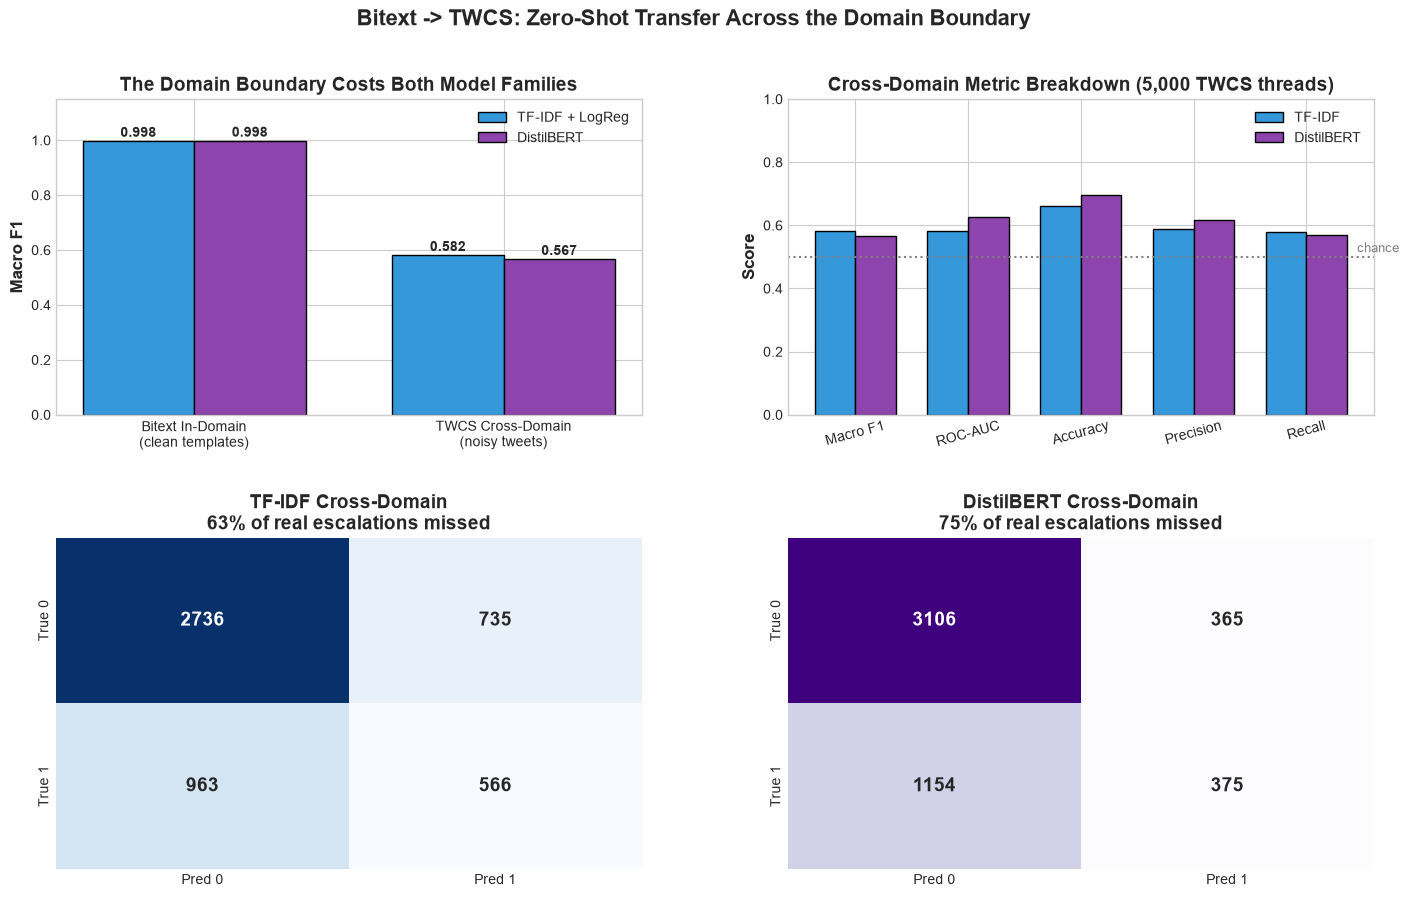

In [14]:
# Cross-domain visual comparison
fig = plt.figure(figsize=(17, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], hspace=0.38, wspace=0.25)

# 1. In-domain vs cross-domain, grouped by model
ax1 = fig.add_subplot(gs[0, 0])
xpos = np.arange(2); width = 0.36
ax1.bar(xpos - width/2, [tfidf_indomain["f1_macro"], tfidf_cross["f1_macro"]], width,
        color="#3498db", edgecolor="black", label="TF-IDF + LogReg")
ax1.bar(xpos + width/2, [bert_indomain["f1_macro"], bert_cross["f1_macro"]], width,
        color="#8e44ad", edgecolor="black", label="DistilBERT")
for i, (a, b) in enumerate(zip([tfidf_indomain["f1_macro"], tfidf_cross["f1_macro"]],
                               [bert_indomain["f1_macro"], bert_cross["f1_macro"]])):
    ax1.text(i - width/2, a + 0.015, f"{a:.3f}", ha="center", fontweight="bold", fontsize=10)
    ax1.text(i + width/2, b + 0.015, f"{b:.3f}", ha="center", fontweight="bold", fontsize=10)
ax1.set_xticks(xpos); ax1.set_xticklabels(["Bitext In-Domain\n(clean templates)", "TWCS Cross-Domain\n(noisy tweets)"])
ax1.set_ylabel("Macro F1"); ax1.set_ylim(0, 1.15)
ax1.set_title("The Domain Boundary Costs Both Model Families")
ax1.legend(loc="upper right", fontsize=10)

# 2. Cross-domain metric spread
ax2 = fig.add_subplot(gs[0, 1])
metric_keys = ["f1_macro", "roc_auc", "accuracy", "precision_macro", "recall_macro"]
metric_labels = ["Macro F1", "ROC-AUC", "Accuracy", "Precision", "Recall"]
xpos = np.arange(len(metric_keys))
ax2.bar(xpos - width/2, [tfidf_cross[k] for k in metric_keys], width,
        color="#3498db", edgecolor="black", label="TF-IDF")
ax2.bar(xpos + width/2, [bert_cross[k] for k in metric_keys], width,
        color="#8e44ad", edgecolor="black", label="DistilBERT")
ax2.axhline(0.5, ls=":", color="grey", lw=1.5)
ax2.text(len(metric_keys) - 0.55, 0.515, "chance", fontsize=9, color="grey")
ax2.set_xticks(xpos); ax2.set_xticklabels(metric_labels, rotation=15)
ax2.set_ylabel("Score"); ax2.set_ylim(0, 1.0)
ax2.set_title("Cross-Domain Metric Breakdown (5,000 TWCS threads)")
ax2.legend(fontsize=10)

# 3-4. Confusion matrices side by side
for j, (name, pred, color) in enumerate(
    [("TF-IDF", pred_tfidf_cross, "Blues"), ("DistilBERT", pred_bert_cross, "Purples")]
):
    ax = fig.add_subplot(gs[1, j])
    c = binary_metrics(y_twcs, pred, prob_tfidf_cross if j == 0 else prob_bert_cross)["confusion_matrix"]
    sns.heatmap(np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]]), annot=True, fmt="d",
                cmap=color, cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
                annot_kws={"size": 14, "weight": "bold"})
    missed = c["fn"] / (c["fn"] + c["tp"])
    ax.set_title(f"{name} Cross-Domain\n{missed:.0%} of real escalations missed")

plt.suptitle("Bitext -> TWCS: Zero-Shot Transfer Across the Domain Boundary",
             fontsize=16, fontweight="bold", y=0.97)
plt.show()

---
## 7. Per-Category Transfer: Does the Transformer Fix the Taxonomy Collision?

Notebook 02 found that the baseline's cross-domain failure was **not uniform**. It was concentrated in `registration_problems` (recall `0.20`) and `payment_issue` (`0.35`) — categories whose Twitter phrasing is lexically clear but whose Bitext counterparts (`recover_password`, `check_invoice`) are mapped to *self-service*. The model matched the words correctly and applied the wrong rule.

That diagnosis makes a sharp, falsifiable prediction: **a better text encoder cannot repair it.** The error is in the label mapping, not in the representation. If DistilBERT's per-category recall follows the same profile, the ceiling on this transfer is set by the taxonomy, and no encoder upgrade will move it.

Read the `delta` column with Section 6's calibration finding in hand: at the `0.5` threshold DistilBERT escalates far less often than the baseline, so its recall is depressed **everywhere**. The informative signal is therefore not the sign of the delta but the **ordering** of the categories, and whether the two models rank the same intents as hardest.

In [15]:
esc_mask = (y_twcs.values == 1)
esc = df_twcs.loc[esc_mask].copy()
esc["pred_tfidf"] = pred_tfidf_cross[esc_mask]
esc["pred_bert"] = pred_bert_cross[esc_mask]

per_cat = (esc.groupby("category")
              .agg(threads=("pred_bert", "size"),
                   tfidf_recall=("pred_tfidf", "mean"),
                   distilbert_recall=("pred_bert", "mean"))
              .sort_values("distilbert_recall", ascending=False))
per_cat["delta"] = (per_cat["distilbert_recall"] - per_cat["tfidf_recall"]).round(3)
per_cat[["tfidf_recall", "distilbert_recall"]] = per_cat[["tfidf_recall", "distilbert_recall"]].round(3)

print("Cross-domain recall per escalation category (Bitext-trained models):\n")
display(per_cat)

# Specificity on the self-service majority class
ss_mask = ~esc_mask
print(f"\nSelf-service specificity (correctly left un-escalated), {int(ss_mask.sum()):,d} threads:")
print(f"  TF-IDF     : {(pred_tfidf_cross[ss_mask] == 0).mean():.3f}")
print(f"  DistilBERT : {(pred_bert_cross[ss_mask] == 0).mean():.3f}")

Cross-domain recall per escalation category (Bitext-trained models):



,threads,tfidf_recall,distilbert_recall,delta
category,,,,
check_cancellation_fee,18,0.722,0.611,-0.111
contact_human_agent,65,0.600,0.477,-0.123
contact_customer_service,169,0.515,0.278,-0.237
get_refund,112,0.518,0.268,-0.250
complaint,759,0.323,0.245,-0.078
payment_issue,281,0.352,0.210,-0.142
registration_problems,125,0.200,0.088,-0.112



Self-service specificity (correctly left un-escalated), 3,471 threads:
  TF-IDF     : 0.788
  DistilBERT : 0.895


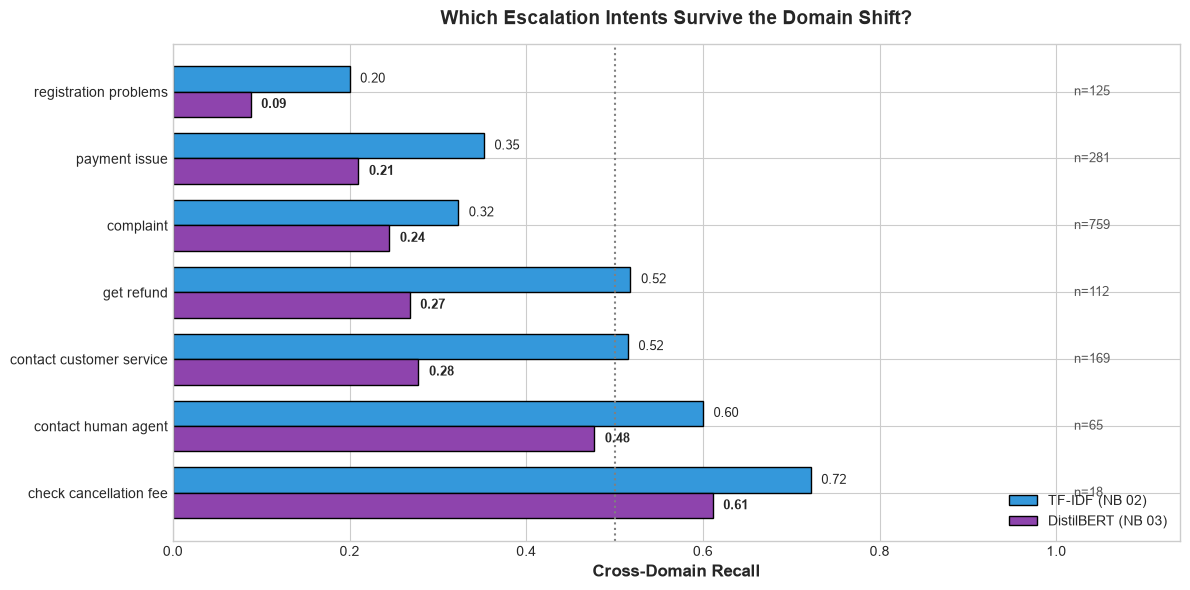

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
cats = per_cat.index.tolist()
ypos = np.arange(len(cats)); height = 0.38

ax.barh(ypos + height/2, per_cat["tfidf_recall"], height,
        color="#3498db", edgecolor="black", label="TF-IDF (NB 02)")
ax.barh(ypos - height/2, per_cat["distilbert_recall"], height,
        color="#8e44ad", edgecolor="black", label="DistilBERT (NB 03)")

for i, (t, b, n) in enumerate(zip(per_cat["tfidf_recall"], per_cat["distilbert_recall"], per_cat["threads"])):
    ax.text(t + 0.012, i + height/2, f"{t:.2f}", va="center", fontsize=9)
    ax.text(b + 0.012, i - height/2, f"{b:.2f}", va="center", fontsize=9, fontweight="bold")
    ax.text(1.02, i, f"n={n}", va="center", fontsize=9, color="#555")

ax.set_yticks(ypos)
ax.set_yticklabels([c.replace("_", " ") for c in cats])
ax.set_xlabel("Cross-Domain Recall")
ax.set_xlim(0, 1.14)
ax.axvline(0.5, ls=":", color="grey", lw=1.5)
ax.set_title("Which Escalation Intents Survive the Domain Shift?", pad=14)
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Persisting Artifacts

The fine-tuned weights and the full metric record are written to `models/bitext/distilbert/`. Notebook 04 reads `bitext_distilbert_metrics.json` to build the final four-model comparison, and the Streamlit triage simulator can load the weights directly.

In [17]:
MODEL_OUT = os.path.join(REPO_ROOT, "models", "bitext", "distilbert")
METRICS_OUT = os.path.join(REPO_ROOT, "models", "bitext", "distilbert", "bitext_distilbert_metrics.json")

save_model(model, tokenizer, MODEL_OUT)

metrics_payload = {
    "model_name": "DistilBERT (distilbert-base-uncased), fine-tuned on Bitext",
    "train_samples": len(X_train),
    "val_samples": len(X_val),
    "test_samples": len(X_test),
    "train_duration_sec": train_meta["train_duration_sec"],
    "best_epoch": train_meta["best_epoch"],
    "best_val_macro_f1": train_meta["best_val_macro_f1"],
    "hyperparameters": train_meta["hyperparameters"],
    "training_history": train_meta["history"],
    "in_domain_bitext": bert_indomain,
    "cross_domain_twcs": bert_cross,
    "cross_domain_twcs_tfidf_reference": tfidf_cross,
    "cross_domain_threshold_calibration": {
        "note": ("Oracle upper bound: threshold selected on the evaluation set itself. "
                 "Quantifies the calibration component of the gap, not a deployable score."),
        "tfidf": {"best_threshold": round(thr_tfidf, 3), "best_macro_f1": round(f1_tfidf_oracle, 4)},
        "distilbert": {"best_threshold": round(thr_bert, 3), "best_macro_f1": round(f1_bert_oracle, 4)},
    },
    "per_category_cross_domain_recall": {
        cat: {
            "threads": int(row["threads"]),
            "tfidf_recall": float(row["tfidf_recall"]),
            "distilbert_recall": float(row["distilbert_recall"]),
        }
        for cat, row in per_cat.iterrows()
    },
    "latency_benchmark": {
        f"avg_inference_ms_per_query_{DEVICE.type}": round(lat_gpu, 4),
        "avg_inference_ms_per_query_cpu": round(lat_cpu, 4),
        "tfidf_reference_ms_per_query": tfidf_latency,
        "test_iterations": 500,
        "batch_size": 1,
    },
}

save_metrics(metrics_payload, METRICS_OUT)
print(f"Saved fine-tuned model  -> {os.path.relpath(MODEL_OUT, REPO_ROOT)}")
print(f"Saved evaluation record -> {os.path.relpath(METRICS_OUT, REPO_ROOT)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model  -> models/bitext/distilbert
Saved evaluation record -> models/bitext/bitext_distilbert_metrics.json


### What Comes Next? (The In-Domain Ceiling)

We've measured zero-shot transfer for models that have never seen a tweet. Now we need to isolate the performance gap: how much is missing vocabulary vs. architectural limits?

**Next Steps:**
1. **Notebook 04**: Fine-tune DistilBERT directly on TWCS (in-domain) to complete the 2x2 matrix and decompose the exact performance gaps.
2. **Notebook 05**: Compare uncased against cased to test if casing recovers any lost signal.